In [21]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
#import pystuff as ps
# import cartopy.crs as ccrs
# import cartopy.feature as cf
# import seaborn as sns
# import matplotlib.patches as patches
from scipy import stats
import cmocean
import glob
from cmcrameri import cm
# from tqdm.notebook import tqdm_notebook

In [22]:
import warnings
warnings.simplefilter(action='ignore')

In [23]:
import os

folder_name = "figure_TCo95"              
save_dir = os.path.join(os.getcwd(), folder_name)  
os.makedirs(save_dir, exist_ok=True) 

In [24]:
def load_var(var, ncname, vname):
    past_path   = f"{base_path}TCo95.{ncname}.monthly.1950-1969.nc"
    future_path = f"{base_path}TCo95.{ncname}.monthly.2080-2092.nc"
    return (
        xr.open_dataset(past_path)[vname],
        xr.open_dataset(future_path)[vname],
    )

In [25]:
# variable names
var_map = {
    '2t':  '2t',
    'tp':  'cp',
    'lcc': 'lcc',
    'mcc': 'mcc',
    'hcc': 'hcc',
    'tcc': 'tcc',
    '10ws':  '10ws',
    'sst': 'sst',
}
base_path = "/proj/eunbyeol/Hackathon2025_AG/data/Scale_Thomas/TCo95_monmean/"


In [26]:
past = {}
future = {}

for ncname, vname in var_map.items():
    past[ncname], future[ncname] = load_var(ncname, ncname, vname)


In [27]:
t2_p = past['2t']-273
t2_f = future['2t']-273
tp_p = past['tp']*4000
tp_f = future['tp']*4000
lcc_p = past['lcc']
lcc_f = future['lcc']
mcc_p = past['mcc']
mcc_f = future['mcc']
hcc_p = past['hcc']
hcc_f = future['hcc']
tcc_p = past['tcc']
tcc_f = future['tcc']
ws_p = past['10ws']
ws_f = future['10ws']
sst_p = past['sst']-273
sst_f = future['sst']-273


In [28]:
def calc_diff(p, f, name=None):
    diff = xr.DataArray(
        f.values - p.values,
        dims=p.dims,
        coords=p.coords,
        name=name
    )
    return diff

In [29]:
t2_diff  = calc_diff(t2_p, t2_f, name='t2_diff')
tp_diff = calc_diff(tp_p, tp_f, name='tp_diff')
lcc_diff = calc_diff(lcc_p, lcc_f, name='lcc_diff')
mcc_diff = calc_diff(mcc_p, mcc_f, name='mcc_diff')
hcc_diff = calc_diff(hcc_p, hcc_f, name='hcc_diff')
tcc_diff = calc_diff(tcc_p, tcc_f, name='tcc_diff')
ws_diff = calc_diff(ws_p, ws_f, name='ws_diff')
sst_diff = calc_diff(sst_p, sst_f, name='sst_diff')


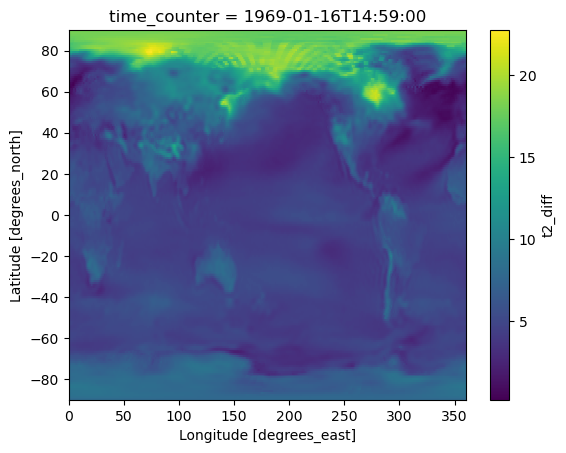

In [30]:
t2_test = t2_diff[0,:,:]
t2_test.plot()

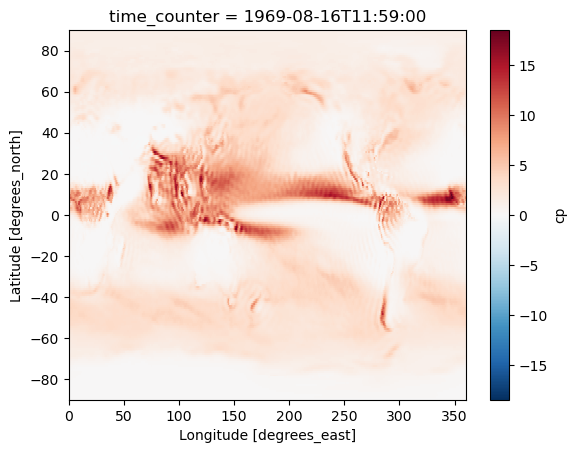

In [31]:
tp_test = tp_p[7,:,:]
tp_test.plot()

In [32]:
def seasonal_mean(da, months):

    if 'month' not in da.coords:
        if np.issubdtype(da['time_counter'].dtype, np.datetime64):
            da = da.assign_coords(month=da['time_counter'].dt.month)
        else:
            da = da.assign_coords(month=(da['time_counter'] % 12) + 1)
    
    return da.where(da.month.isin(months), drop=True).mean('time_counter')


In [33]:
# t2_diff
t2_DJF = seasonal_mean(t2_diff, [1,2,12])
t2_MAM = seasonal_mean(t2_diff, [3,4,5])
t2_JJA = seasonal_mean(t2_diff, [6,7,8])
t2_SON = seasonal_mean(t2_diff, [9,10,11])

# tp_diff
tp_DJF = seasonal_mean(tp_diff, [1,2,12])
tp_JJA = seasonal_mean(tp_diff, [6,7,8])
tp_MAM = seasonal_mean(tp_diff, [3,4,5])
tp_SON = seasonal_mean(tp_diff, [9,10,11])

# lcc_diff
lcc_DJF = seasonal_mean(lcc_diff, [1,2,12])
lcc_JJA = seasonal_mean(lcc_diff, [6,7,8])
lcc_MAM = seasonal_mean(lcc_diff, [3,4,5])
lcc_SON = seasonal_mean(lcc_diff, [9,10,11])

# mcc_diff
mcc_DJF = seasonal_mean(mcc_diff, [1,2,12])
mcc_JJA = seasonal_mean(mcc_diff, [6,7,8])
mcc_MAM = seasonal_mean(mcc_diff, [3,4,5])
mcc_SON = seasonal_mean(mcc_diff, [9,10,11])

# hcc_diff
hcc_DJF = seasonal_mean(hcc_diff, [1,2,12])
hcc_JJA = seasonal_mean(hcc_diff, [6,7,8])
hcc_MAM = seasonal_mean(hcc_diff, [3,4,5])
hcc_SON = seasonal_mean(hcc_diff, [9,10,11])

# tcc_diff
tcc_DJF = seasonal_mean(tcc_diff, [1,2,12])
tcc_JJA = seasonal_mean(tcc_diff, [6,7,8])
tcc_MAM = seasonal_mean(tcc_diff, [3,4,5])
tcc_SON = seasonal_mean(tcc_diff, [9,10,11])

# ws_diff
ws_DJF = seasonal_mean(ws_diff, [1,2,12])
ws_JJA = seasonal_mean(ws_diff, [6,7,8])
ws_MAM = seasonal_mean(ws_diff, [3,4,5])
ws_SON = seasonal_mean(ws_diff, [9,10,11])

# sst_diff
sst_DJF = seasonal_mean(sst_diff, [1,2,12])
sst_JJA = seasonal_mean(sst_diff, [6,7,8])
sst_MAM = seasonal_mean(sst_diff, [3,4,5])
sst_SON = seasonal_mean(sst_diff, [9,10,11])

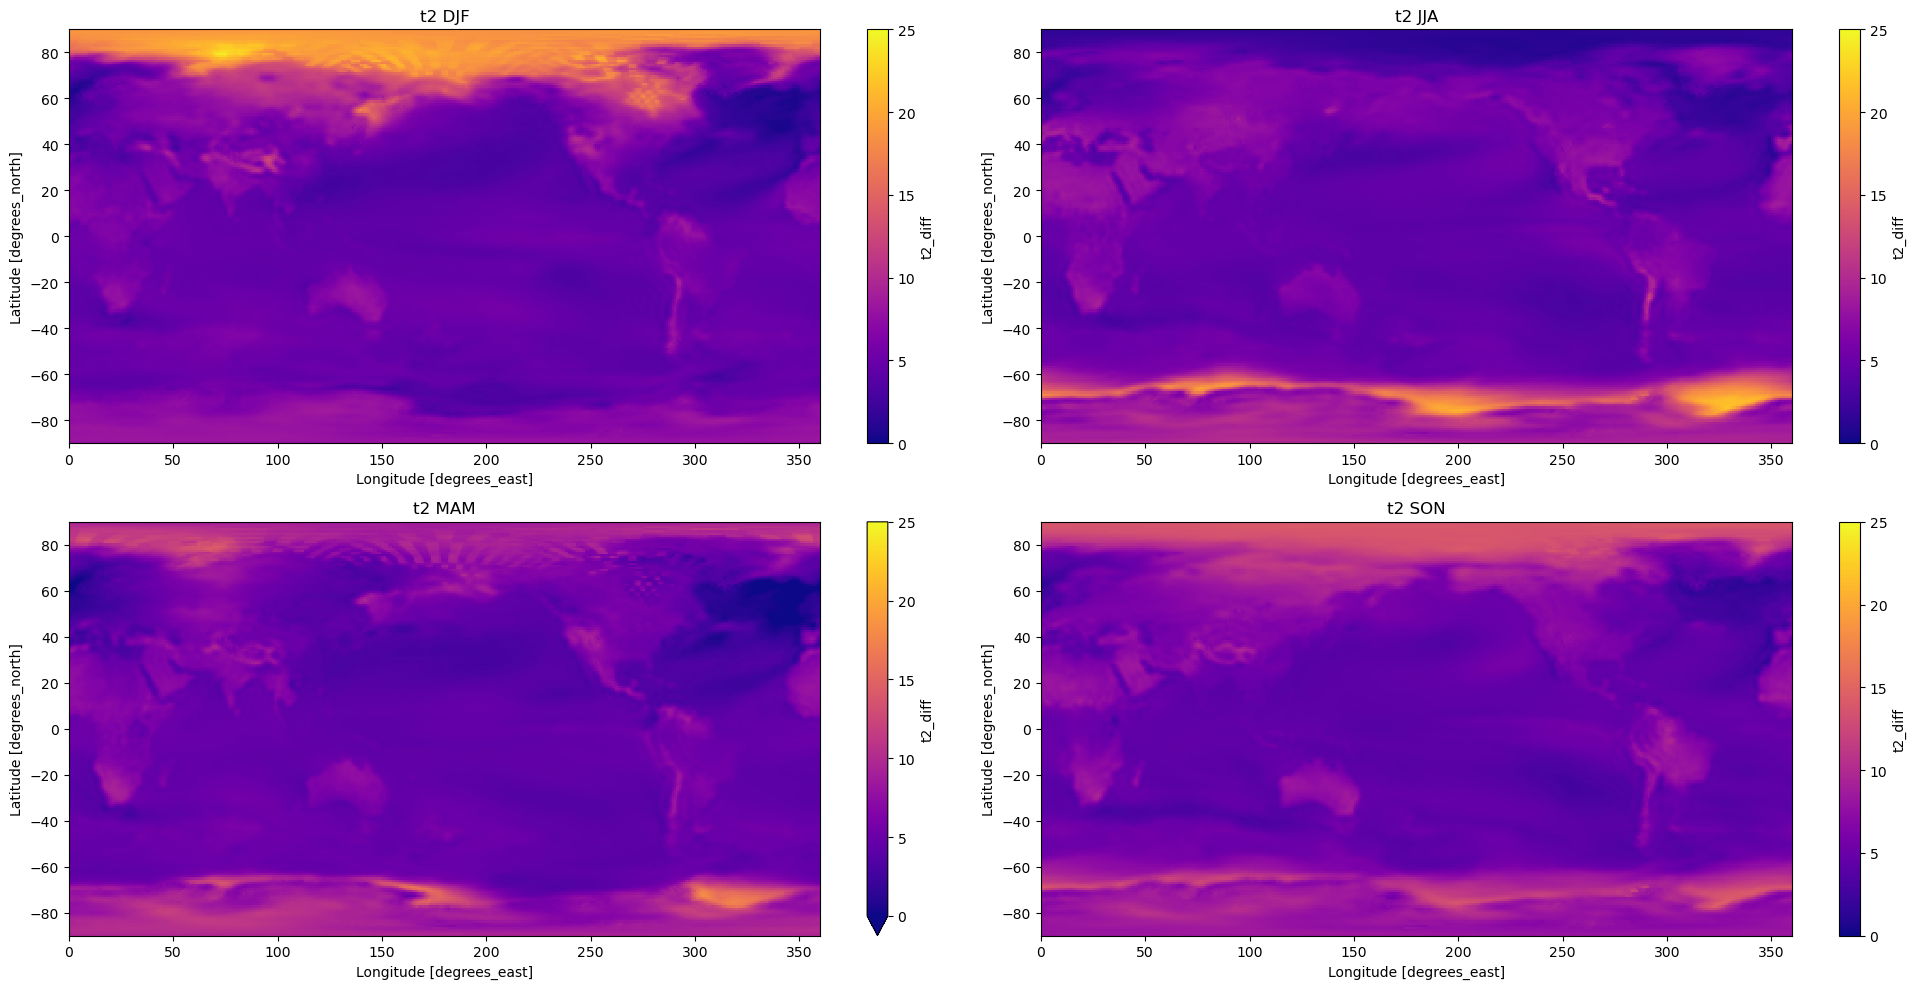

In [34]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(20, 10))

t2_DJF.plot(ax=axes[0, 0], cmap="plasma", vmin=0, vmax=25)
axes[0, 0].set_title("t2 DJF")

t2_JJA.plot(ax=axes[0, 1], cmap="plasma", vmin=0, vmax=25)
axes[0, 1].set_title("t2 JJA")

t2_MAM.plot(ax=axes[1, 0], cmap="plasma", vmin=0, vmax=25)
axes[1, 0].set_title("t2 MAM")

t2_SON.plot(ax=axes[1, 1], cmap="plasma", vmin=0, vmax=25)
axes[1, 1].set_title("t2 SON")

plt.tight_layout()
plt.show()


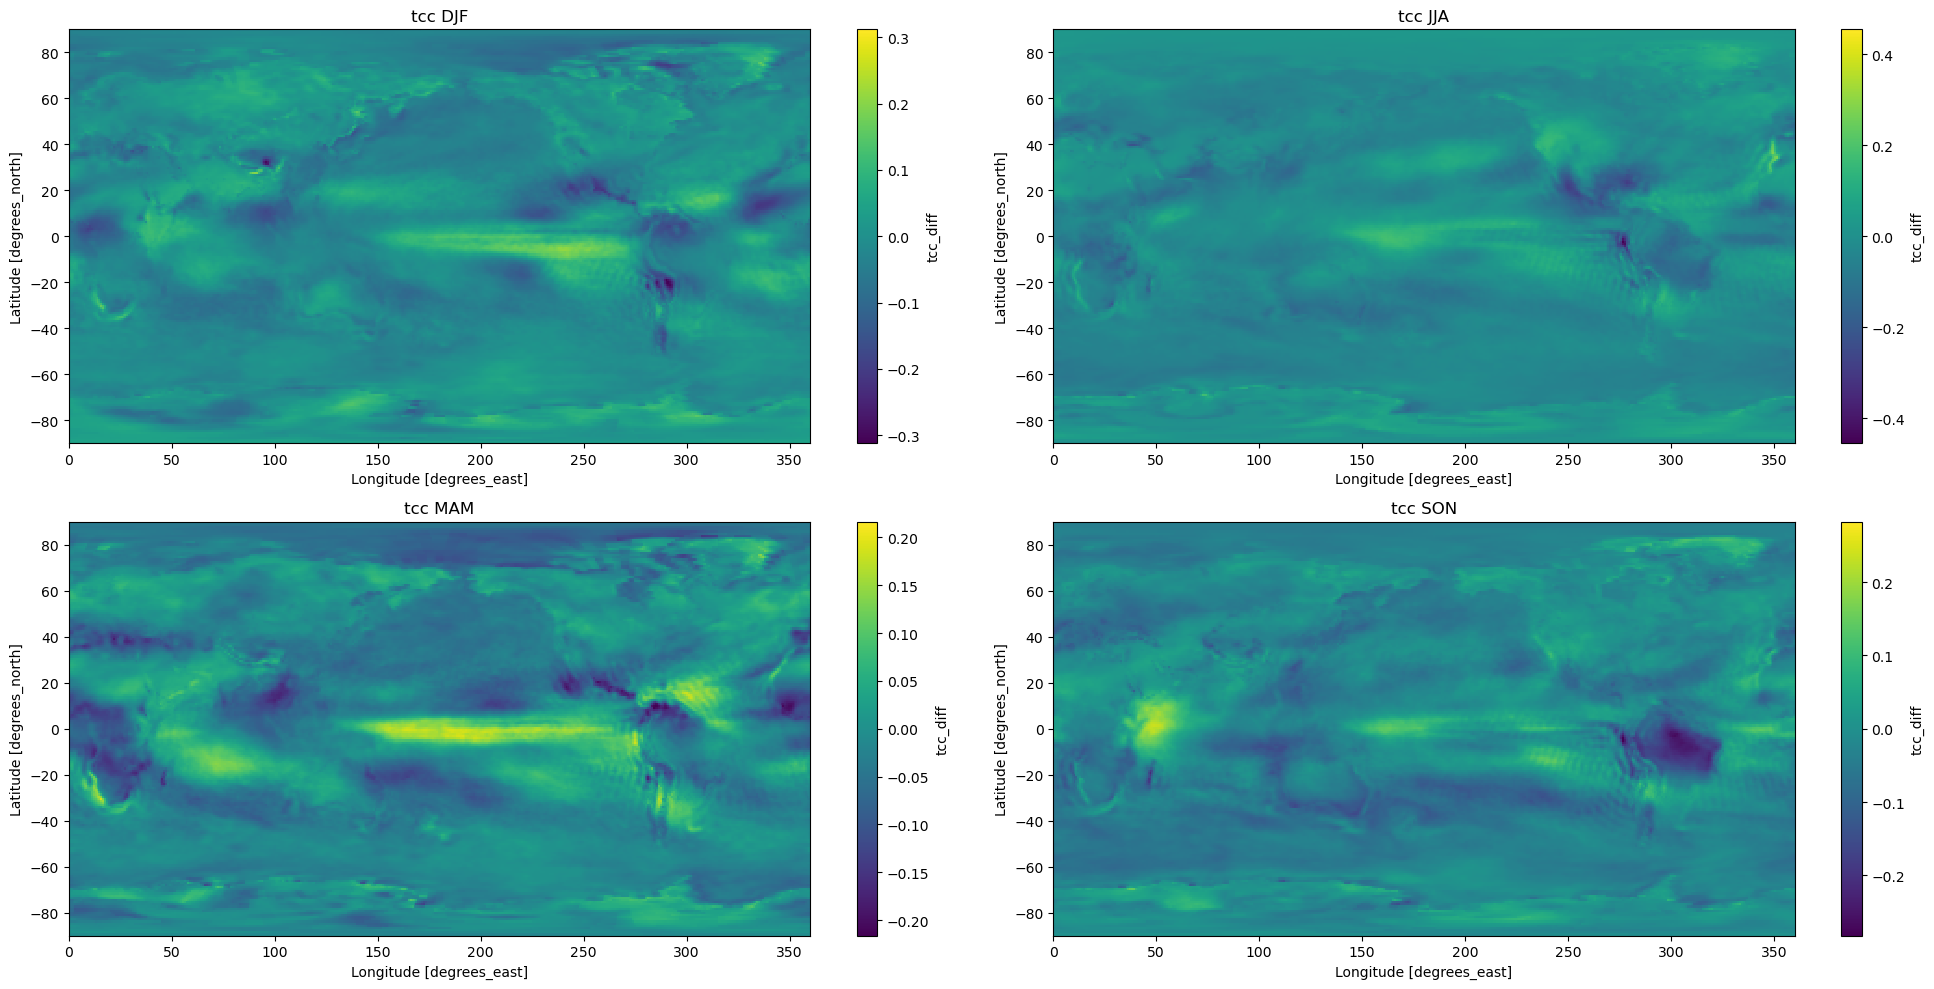

In [35]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(20, 10))

tcc_DJF.plot(ax=axes[0, 0], cmap="viridis")
axes[0, 0].set_title("tcc DJF")

tcc_JJA.plot(ax=axes[0, 1], cmap="viridis")
axes[0, 1].set_title("tcc JJA")

tcc_MAM.plot(ax=axes[1, 0], cmap="viridis")
axes[1, 0].set_title("tcc MAM")

tcc_SON.plot(ax=axes[1, 1], cmap="viridis")
axes[1, 1].set_title("tcc SON")

plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'sst JJA')

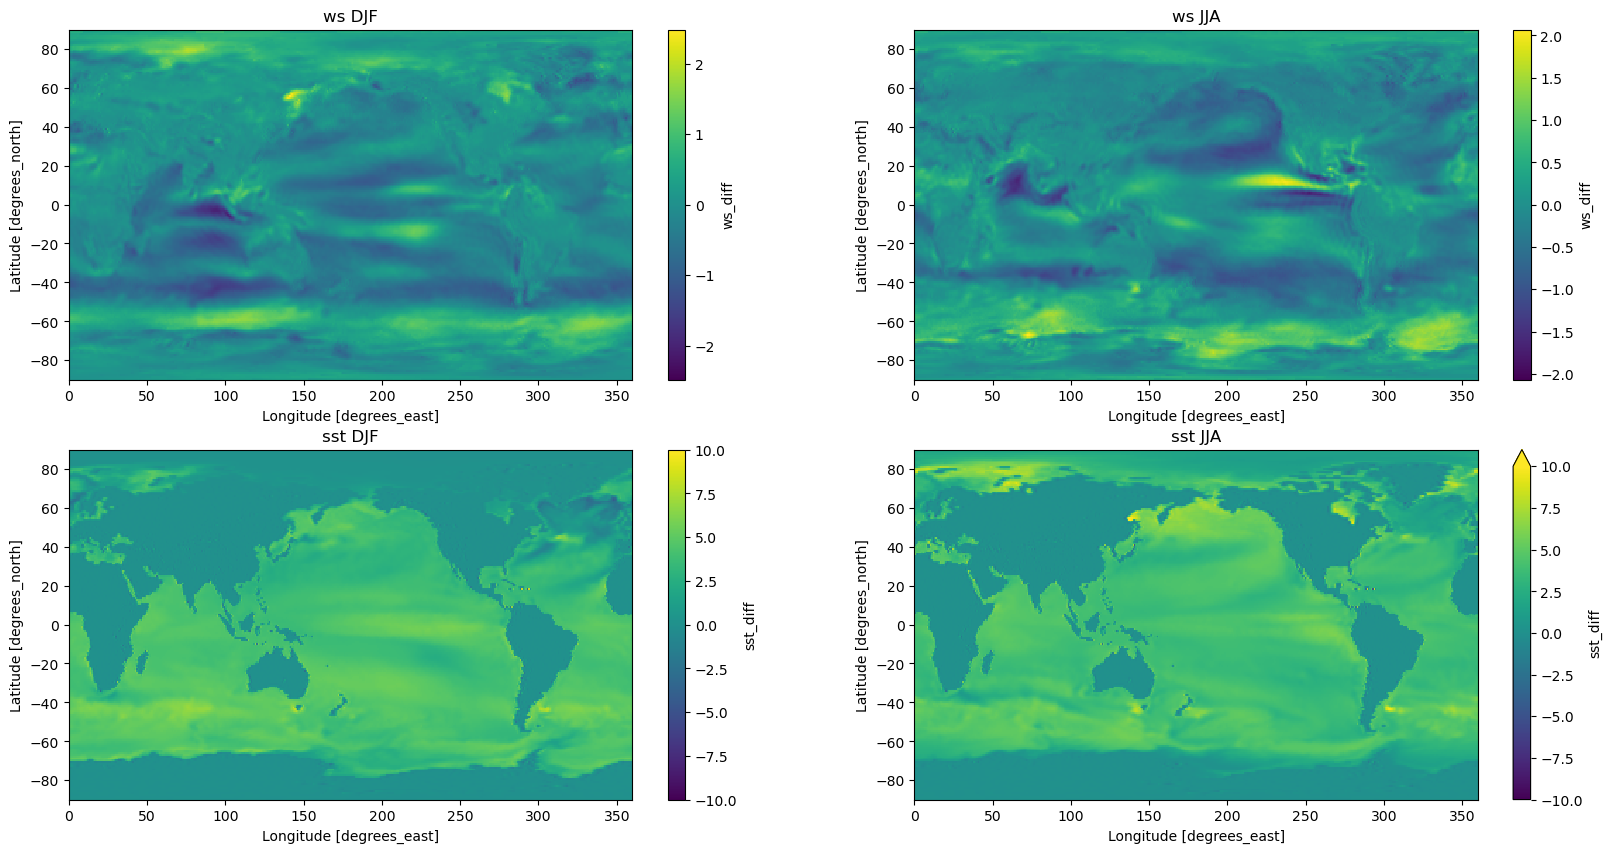

In [36]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(20, 10))

ws_DJF.plot(ax=axes[0, 0], cmap="viridis")
axes[0, 0].set_title("ws DJF")

ws_JJA.plot(ax=axes[0, 1], cmap="viridis")
axes[0, 1].set_title("ws JJA")

sst_DJF.plot(ax=axes[1, 0], cmap="viridis",vmin=-10,vmax=10)
axes[1, 0].set_title("sst DJF")

sst_JJA.plot(ax=axes[1, 1], cmap="viridis",vmin=-10,vmax=10)
axes[1, 1].set_title("sst JJA")



## Scaling

In [37]:
# Define the temperature differences
temp_diff95_DJF = 6.02
temp_diff95_JJA = 5.76
temp_diff95_MAM = 5.67
temp_diff95_SON = 6.29

temp_diff319_DJF = 5.51
temp_diff319_JJA = 5.23
temp_diff319_MAM = 5.13
temp_diff319_SON = 5.44

temp_diff1279_DJF = 5.4
temp_diff1279_JJA = 5.14
temp_diff1279_MAM = 4.93
temp_diff1279_SON = 5.28

In [38]:
# t2_diff/temp_diff95
t2_DJF_scaling = t2_DJF/temp_diff95_DJF
t2_JJA_scaling = t2_JJA/temp_diff95_JJA
t2_MAM_scaling = t2_MAM/temp_diff95_MAM
t2_SON_scaling = t2_SON/temp_diff95_SON

# tp_diff/temp_diff95
tp_DJF_scaling = tp_DJF/temp_diff95_DJF
tp_JJA_scaling = tp_JJA/temp_diff95_JJA
tp_MAM_scaling = tp_MAM/temp_diff95_MAM
tp_SON_scaling = tp_SON/temp_diff95_SON

# lcc_diff/temp_diff95
lcc_DJF_scaling = lcc_DJF/temp_diff95_DJF
lcc_JJA_scaling = lcc_JJA/temp_diff95_JJA
lcc_MAM_scaling = lcc_MAM/temp_diff95_MAM
lcc_SON_scaling = lcc_SON/temp_diff95_SON

# mcc_diff/temp_diff95
mcc_DJF_scaling = mcc_DJF/temp_diff95_DJF
mcc_JJA_scaling = mcc_JJA/temp_diff95_JJA
mcc_MAM_scaling = mcc_MAM/temp_diff95_MAM
mcc_SON_scaling = mcc_SON/temp_diff95_SON

# hcc_diff/temp_diff95
hcc_DJF_scaling = hcc_DJF/temp_diff95_DJF
hcc_JJA_scaling = hcc_JJA/temp_diff95_JJA
hcc_MAM_scaling = hcc_MAM/temp_diff95_MAM
hcc_SON_scaling = hcc_SON/temp_diff95_SON

# tcc_diff/temp_diff95
tcc_DJF_scaling = tcc_DJF/temp_diff95_DJF
tcc_JJA_scaling = tcc_JJA/temp_diff95_JJA
tcc_MAM_scaling = tcc_MAM/temp_diff95_MAM
tcc_SON_scaling = tcc_SON/temp_diff95_SON

# ws_diff/temp_diff95
ws_DJF_scaling = ws_DJF/temp_diff95_DJF
ws_JJA_scaling = ws_JJA/temp_diff95_JJA
ws_MAM_scaling = ws_MAM/temp_diff95_MAM
ws_SON_scaling = ws_SON/temp_diff95_SON

# sst_diff/temp_diff95
sst_DJF_scaling = sst_DJF/temp_diff95_DJF
sst_JJA_scaling = sst_JJA/temp_diff95_JJA
sst_MAM_scaling = sst_MAM/temp_diff95_MAM
sst_SON_scaling = sst_SON/temp_diff95_SON


Figure saved to: /mnt/lustre/proj/eunbyeol/Hackathon2025_AG_Scaling/figure_TCo95/TCo95_2t_tp_seasons.png


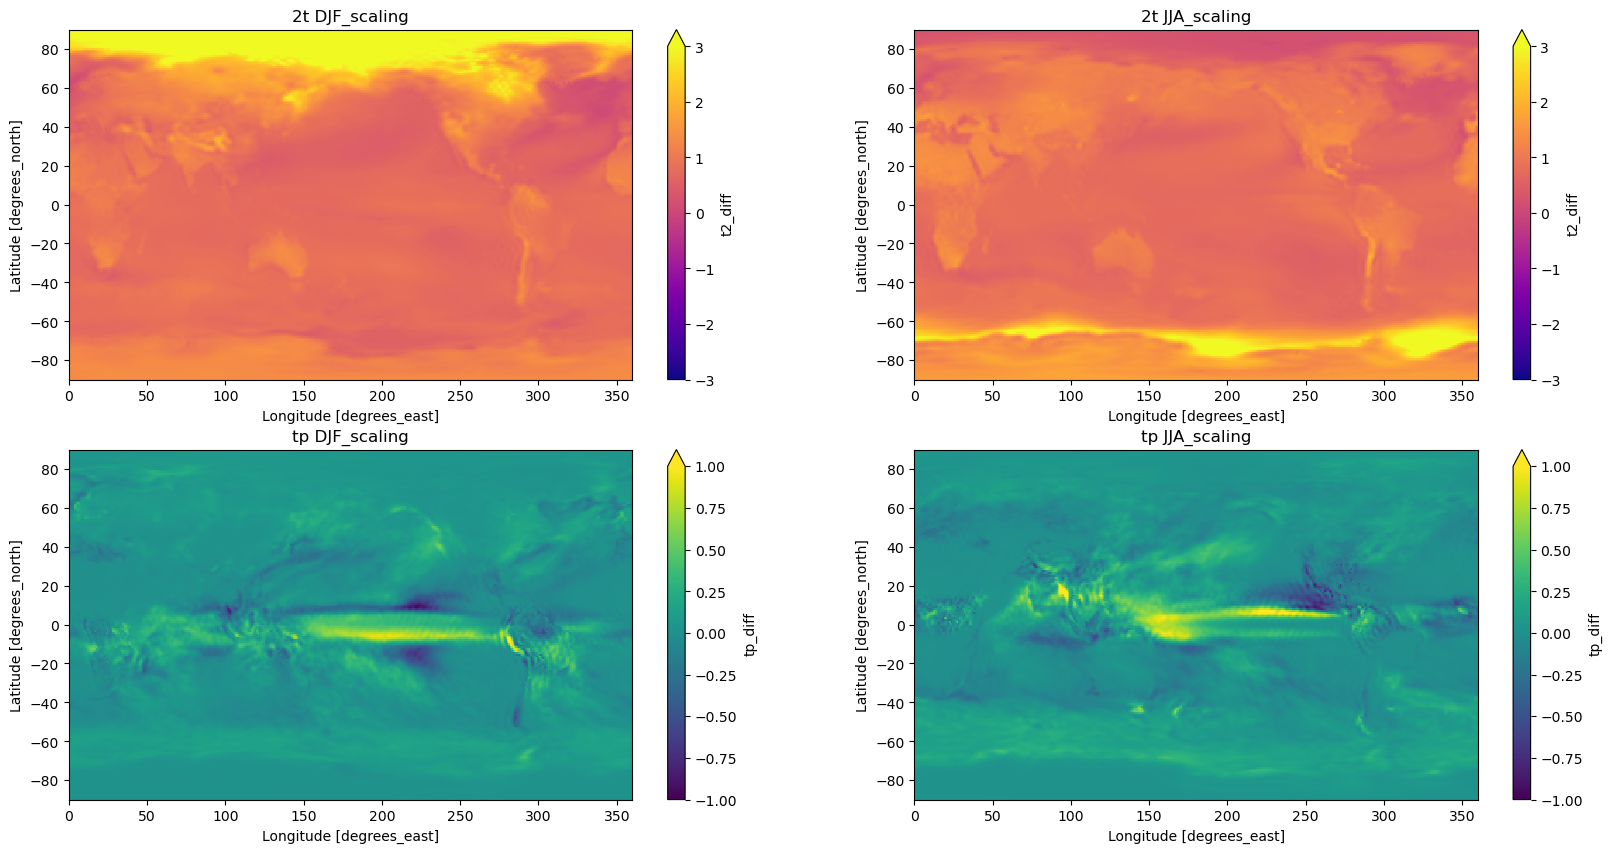

In [39]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(20, 10))

t2_DJF_scaling.plot(ax=axes[0, 0], cmap="plasma", vmin=-3, vmax=3)
axes[0, 0].set_title("2t DJF_scaling")

t2_JJA_scaling.plot(ax=axes[0, 1], cmap="plasma", vmin=-3, vmax=3)
axes[0, 1].set_title("2t JJA_scaling")

tp_DJF_scaling.plot(ax=axes[1, 0], cmap="viridis", vmin=-1, vmax=1)
axes[1, 0].set_title("tp DJF_scaling")

tp_JJA_scaling.plot(ax=axes[1, 1], cmap="viridis", vmin=-1, vmax=1)
axes[1, 1].set_title("tp JJA_scaling")

save_path = os.path.join(save_dir, "TCo95_2t_tp_seasons.png")
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {save_path}")  

plt.show()

In [40]:
import cartopy.crs as ccrs
from tqdm.notebook import tqdm_notebook
import cartopy.feature as cf

  0%|          | 0/8 [00:00<?, ?it/s]

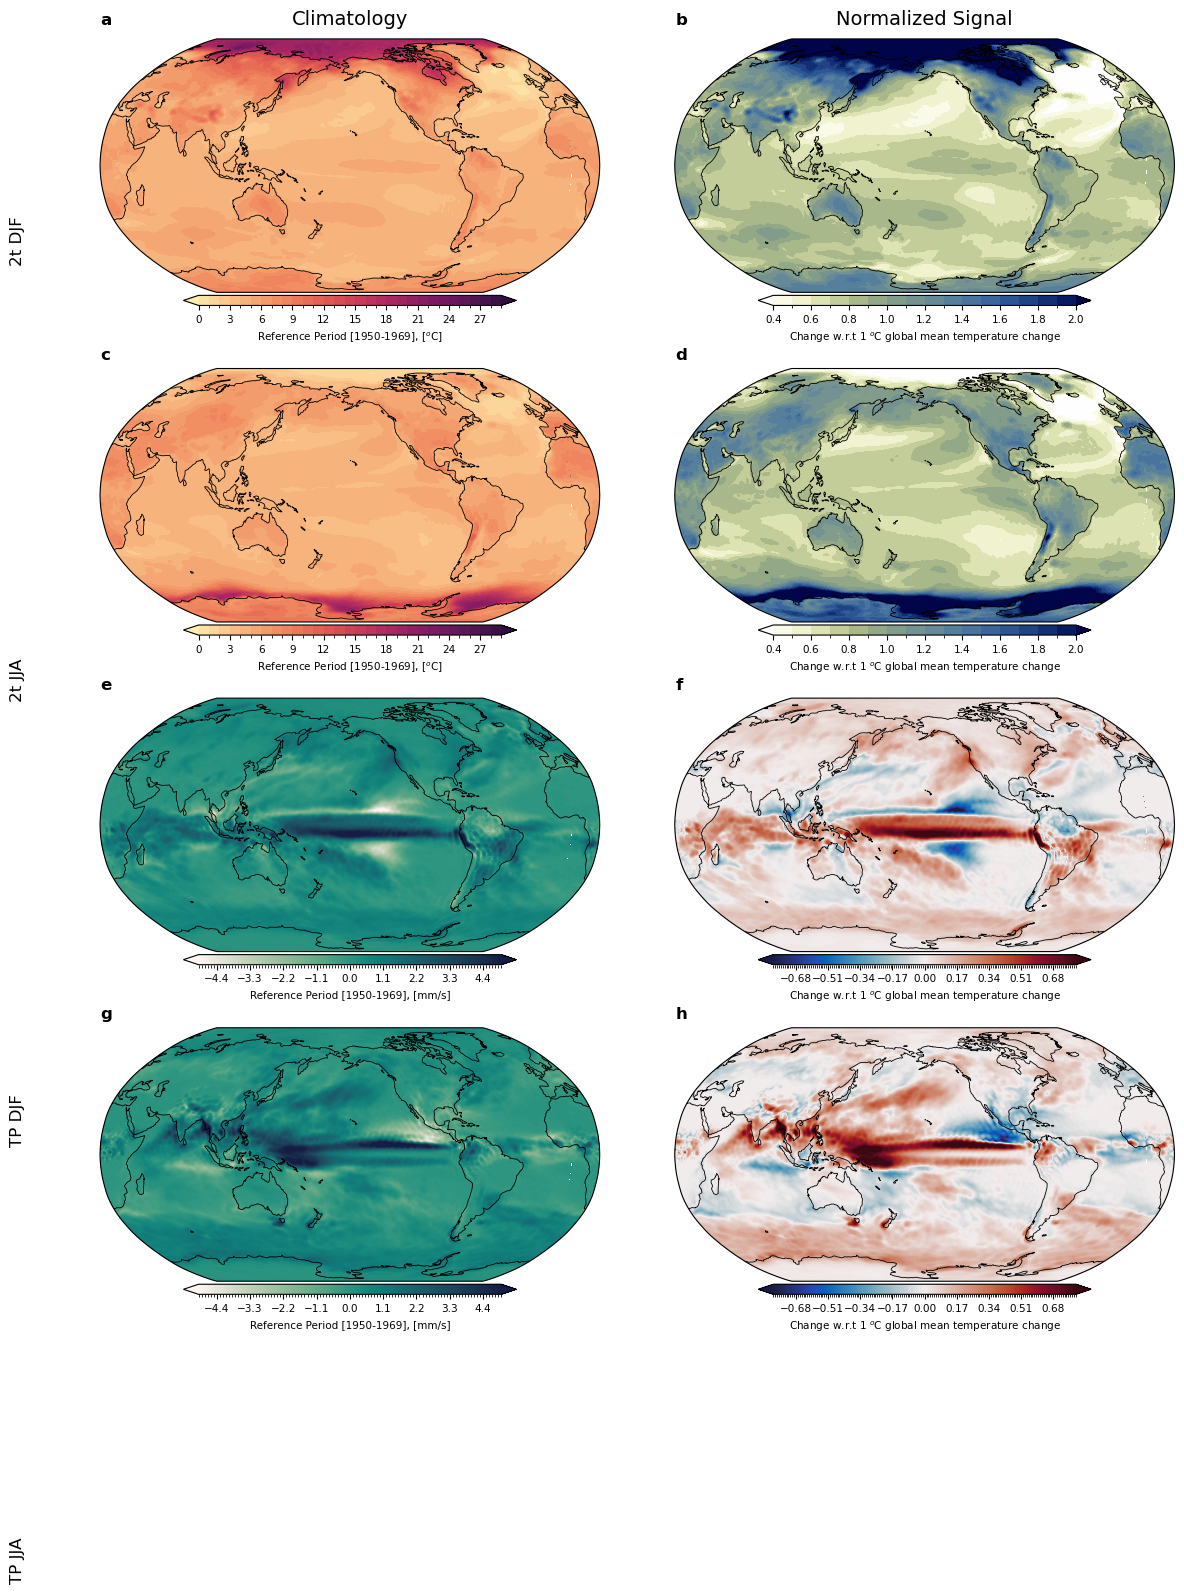

In [41]:


plt.rcParams.update({'font.size': 7.5})
fig,ax = plt.subplots(4,2,figsize=(18.5, 22), dpi=100, facecolor='w', edgecolor='k',subplot_kw={'projection': ccrs.Robinson(central_longitude=200)})

import cmocean
import matplotlib.colors as mcolors

titlesM = ['Climatology', 'Normalized Signal']
titlesL = ['$\mathbf{a}$', '$\mathbf{b}$', '$\mathbf{c}$', '$\mathbf{d}$', '$\mathbf{e}$', '$\mathbf{f}$', '$\mathbf{g}$', '$\mathbf{h}$']
labels = ['2t DJF', '2t JJA', 'TP DJF', 'TP JJA']

fields=[t2_DJF, t2_DJF_scaling,
        t2_JJA, t2_JJA_scaling,
        tp_DJF, tp_DJF_scaling,
        tp_JJA, tp_JJA_scaling,]

levels=[np.arange(0,30,1), np.arange(0.4,2.1,0.1),
        np.arange(0,30,1), np.arange(0.4,2.1,0.1),
        np.arange(-5,5.1,0.1), np.arange(-0.8,0.81,0.01),
        np.arange(-5,5.1,0.1), np.arange(-0.8,0.81,0.01)]

norms = [None, mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=3),
         None, mcolors.TwoSlopeNorm(vmin=-0.6, vcenter=0, vmax=0.65),
         None, mcolors.TwoSlopeNorm(vmin=-1.0, vcenter=0, vmax=1.05)]

cbar=[cmocean.cm.matter, cm.davos_r,
      cmocean.cm.matter, cm.davos_r,
      cmocean.cm.tempo, cmocean.cm.balance,
      cmocean.cm.tempo, cmocean.cm.balance]

units=[ 'Reference Period [1950-1969], [$^{o}$C]', 'Change w.r.t 1 $^{o}$C global mean temperature change',
        'Reference Period [1950-1969], [$^{o}$C]', 'Change w.r.t 1 $^{o}$C global mean temperature change',
        'Reference Period [1950-1969], [mm/s]', 'Change w.r.t 1 $^{o}$C global mean temperature change', 
        'Reference Period [1950-1969], [mm/s]', 'Change w.r.t 1 $^{o}$C global mean temperature change']

for i,a in enumerate(tqdm_notebook(ax.flat)) :
      clabel=('%s'%units[i])
      cbar_kwargs={'orientation':'horizontal','pad':0.01,'shrink':0.55, 'label':clabel, 'aspect':33}
      fields[i].plot.contourf(ax=a,transform=ccrs.PlateCarree(),levels=levels[i],cbar_kwargs=cbar_kwargs,cmap=cbar[i], extend='both')
    # fields[i].plot.contourf(ax=a,transform=ccrs.PlateCarree(),levels=levels[i],norm=norms[i], cbar_kwargs=cbar_kwargs,cmap=cbar[i], extend='both')
      
      a.add_feature(cf.LAND,color='grey')
      a.coastlines(linewidth=0.6,color='black')
      a.set_global()  

for i, label in enumerate(labels):
    fig.text(0.29, 0.86 - i * 0.20, label, transform=fig.transFigure, fontsize=12, va='center', ha='center', rotation=90)
        
for i, a in enumerate(ax.flat):
    a.set_title('%s' % titlesL[i], size=12, loc='left')

    if i <= 1:
        a.set_title('%s' % (titlesM[i]), size=14, y=1.0, pad=10)
    else:
        a.set_title('')
            
plt.tight_layout(rect=[0.3, 0.36, 0.95, 0.97])

# save_path = os.path.join(save_dir, "TCo95_2t_tp_robinson.png")
# fig.savefig(save_path, dpi=300, bbox_inches='tight')
# print(f"Figure saved to: {save_path}") 


Figure saved to: /mnt/lustre/proj/eunbyeol/Hackathon2025_AG_Scaling/figure_TCo95/TCo95_tcc_scaling_seasons.png


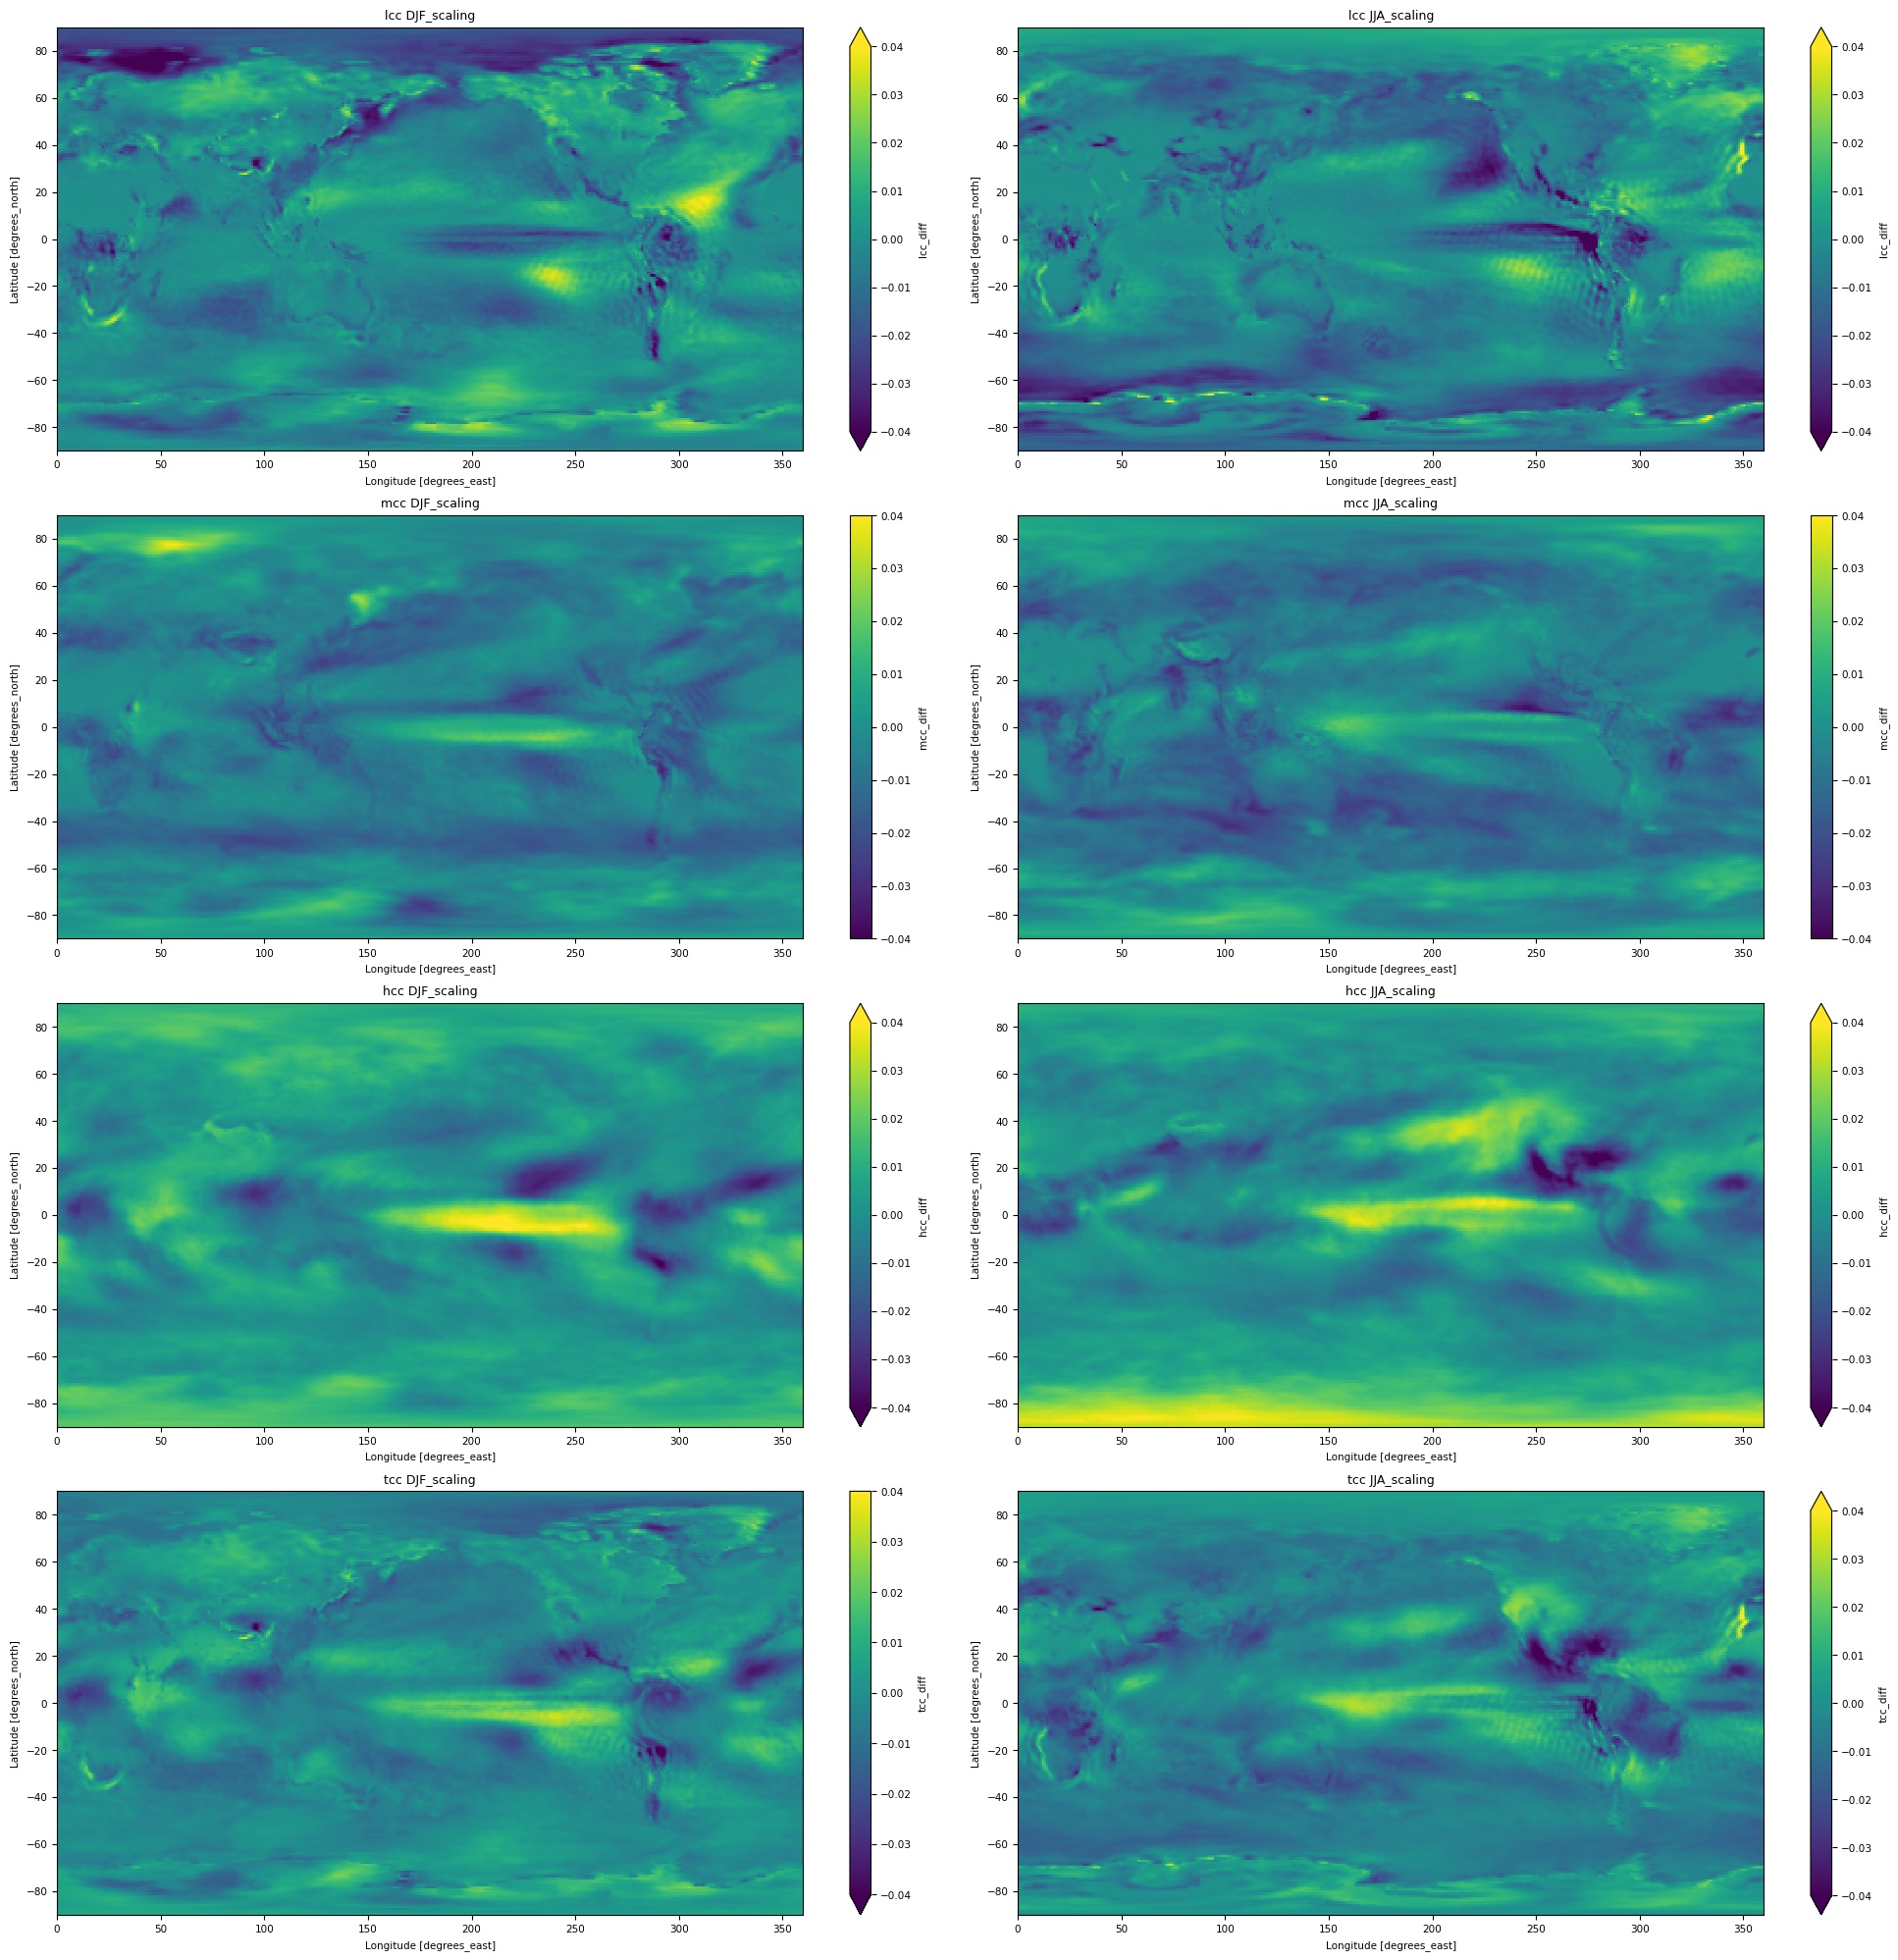

In [42]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 2, figsize=(20, 20))

lcc_DJF_scaling.plot(ax=axes[0, 0], cmap="viridis", vmin=-0.04, vmax=0.04)
axes[0, 0].set_title("lcc DJF_scaling")

lcc_JJA_scaling.plot(ax=axes[0, 1], cmap="viridis", vmin=-0.04, vmax=0.04)
axes[0, 1].set_title("lcc JJA_scaling")

mcc_DJF_scaling.plot(ax=axes[1, 0], cmap="viridis", vmin=-0.04, vmax=0.04)
axes[1, 0].set_title("mcc DJF_scaling")

mcc_JJA_scaling.plot(ax=axes[1, 1], cmap="viridis", vmin=-0.04, vmax=0.04)
axes[1, 1].set_title("mcc JJA_scaling")

hcc_DJF_scaling.plot(ax=axes[2, 0], cmap="viridis", vmin=-0.04, vmax=0.04)
axes[2, 0].set_title("hcc DJF_scaling")

hcc_JJA_scaling.plot(ax=axes[2, 1], cmap="viridis", vmin=-0.04, vmax=0.04)
axes[2, 1].set_title("hcc JJA_scaling")

tcc_DJF_scaling.plot(ax=axes[3, 0], cmap="viridis", vmin=-0.04, vmax=0.04)
axes[3, 0].set_title("tcc DJF_scaling")

tcc_JJA_scaling.plot(ax=axes[3, 1], cmap="viridis", vmin=-0.04, vmax=0.04)
axes[3, 1].set_title("tcc JJA_scaling")

plt.tight_layout()

save_path = os.path.join(save_dir, "TCo95_tcc_scaling_seasons.png")
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {save_path}")  


plt.show()


Figure saved to: /mnt/lustre/proj/eunbyeol/Hackathon2025_AG_Scaling/figure_TCo95/TCo95_ws_sst_scaling_seasons.png


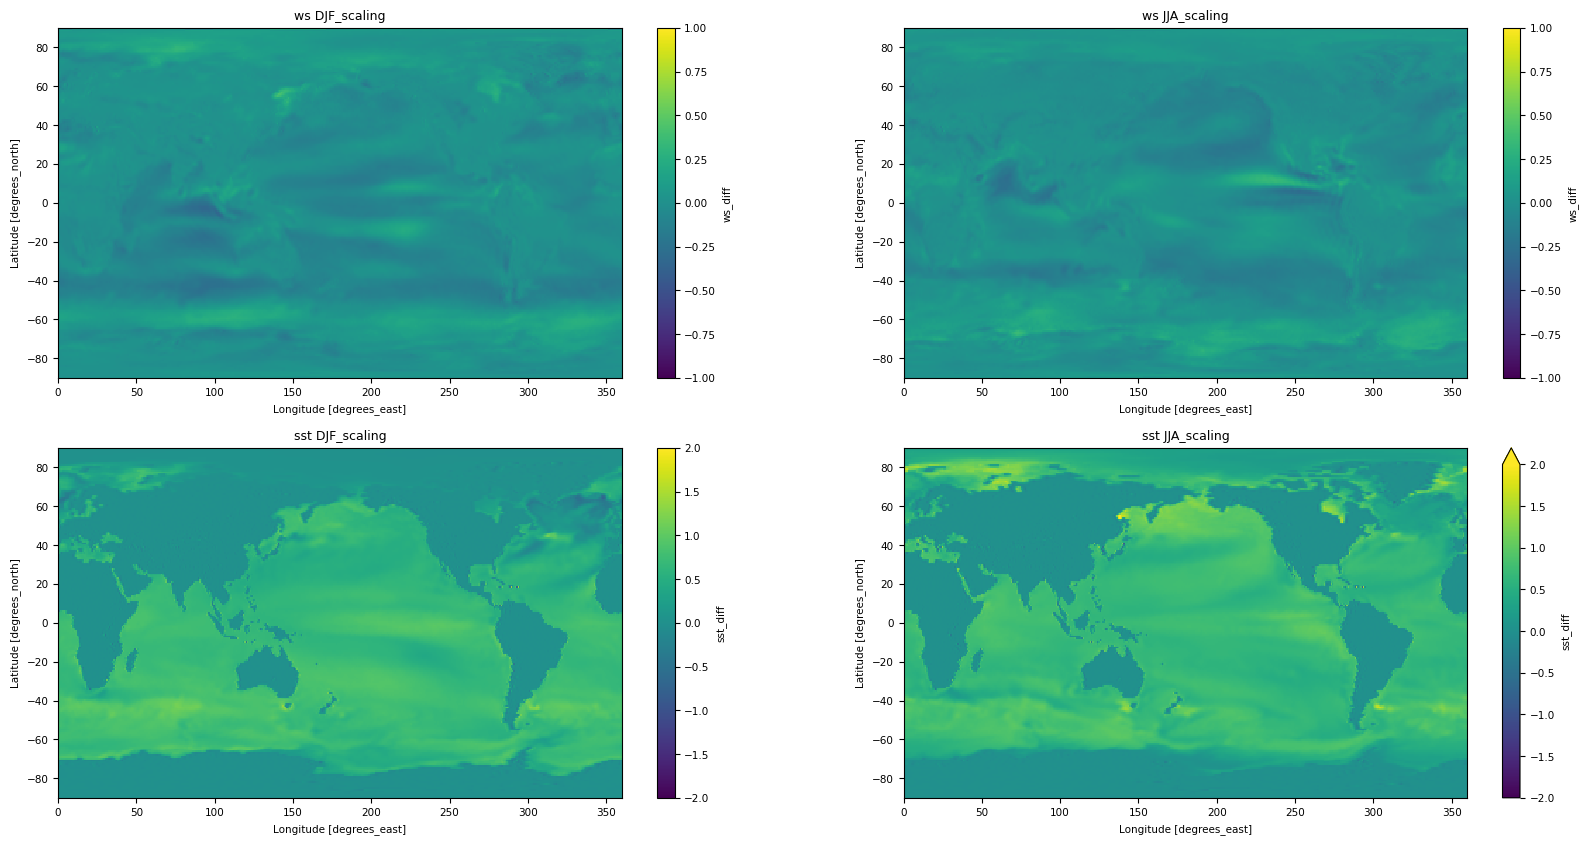

In [44]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(20, 10))

ws_DJF_scaling.plot(ax=axes[0, 0], cmap="viridis", vmin=-1, vmax=1)
axes[0, 0].set_title("ws DJF_scaling")

ws_JJA_scaling.plot(ax=axes[0, 1], cmap="viridis", vmin=-1, vmax=1)
axes[0, 1].set_title("ws JJA_scaling")

sst_DJF_scaling.plot(ax=axes[1, 0], cmap="viridis", vmin=-2, vmax=2)
axes[1, 0].set_title("sst DJF_scaling")

sst_JJA_scaling.plot(ax=axes[1, 1], cmap="viridis", vmin=-2, vmax=2)
axes[1, 1].set_title("sst JJA_scaling")

save_path = os.path.join(save_dir, "TCo95_ws_sst_scaling_seasons.png")
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {save_path}")  


In [45]:
import xarray as xr

var_for_coord = "2t"   # var_map에서 고를 변수 이름
file_path = f"{base_path}TCo95.{var_map[var_for_coord]}.monthly.1950-1969.nc"

ds_coord = xr.open_dataset(file_path)

lon = ds_coord["lon"]
lat = ds_coord["lat"]

In [46]:
lon.shape

(400,)

In [47]:
lat.shape

(192,)

In [48]:
import xarray as xr

# Dataset 생성
ds_out = xr.Dataset(
    {
        "t2_DJF_scaling": t2_DJF_scaling,
        "t2_MAM_scaling": t2_MAM_scaling,
        "t2_JJA_scaling": t2_JJA_scaling,
        "t2_SON_scaling": t2_SON_scaling,

        # "tp_DJF_scaling": tp_DJF_scaling,
        # "tp_JJA_scaling": tp_JJA_scaling,

        # "lcc_DJF_scaling": lcc_DJF_scaling,
        # "lcc_JJA_scaling": lcc_JJA_scaling,

        # "mcc_DJF_scaling": mcc_DJF_scaling,
        # "mcc_JJA_scaling": mcc_JJA_scaling,

        # "hcc_DJF_scaling": hcc_DJF_scaling,
        # "hcc_JJA_scaling": hcc_JJA_scaling,

        # "tcc_DJF_scaling": tcc_DJF_scaling,
        # "tcc_JJA_scaling": tcc_JJA_scaling,

        # "ws_DJF_scaling": ws_DJF_scaling,
        # "ws_JJA_scaling": ws_JJA_scaling,

        # "sst_DJF_scaling": sst_DJF_scaling,
        # "sst_JJA_scaling": sst_JJA_scaling,
    },
    coords={
        "lon": lon,
        "lat": lat,
    }
)

output_path = "scaling_results_TCo95_t2_seasons.nc"
ds_out.to_netcdf(output_path)
print("Saved:", output_path)

Saved: scaling_results_TCo95_t2_seasons.nc


In [49]:
import xarray as xr

# Dataset 생성
ds_out = xr.Dataset(
    {
        "tp_DJF_scaling": tp_DJF_scaling,
        "tp_MAM_scaling": tp_MAM_scaling,
        "tp_JJA_scaling": tp_JJA_scaling,
        "tp_SON_scaling": tp_SON_scaling,
    },
    coords={
        "lon": lon,
        "lat": lat,
    }
)

output_path = "scaling_results_TCo95_tp_seasons.nc"
ds_out.to_netcdf(output_path)
print("Saved:", output_path)

Saved: scaling_results_TCo95_tp_seasons.nc


In [50]:
import xarray as xr

# Dataset 생성
ds_out = xr.Dataset(
    {
        "lcc_DJF_scaling": lcc_DJF_scaling,
        "lcc_MAM_scaling": lcc_MAM_scaling,
        "lcc_JJA_scaling": lcc_JJA_scaling,
        "lcc_SON_scaling": lcc_SON_scaling,
    },
    coords={
        "lon": lon,
        "lat": lat,
    }
)

oulccut_path = "scaling_results_TCo95_lcc_seasons.nc"
ds_out.to_netcdf(oulccut_path)
print("Saved:", oulccut_path)

Saved: scaling_results_TCo95_lcc_seasons.nc


In [51]:
import xarray as xr

# Dataset 생성
ds_out = xr.Dataset(
    {
        "mcc_DJF_scaling": mcc_DJF_scaling,
        "mcc_MAM_scaling": mcc_MAM_scaling,
        "mcc_JJA_scaling": mcc_JJA_scaling,
        "mcc_SON_scaling": mcc_SON_scaling,
    },
    coords={
        "lon": lon,
        "lat": lat,
    }
)

oumccut_path = "scaling_results_TCo95_mcc_seasons.nc"
ds_out.to_netcdf(oumccut_path)
print("Saved:", oumccut_path)

Saved: scaling_results_TCo95_mcc_seasons.nc


In [52]:
import xarray as xr

# Dataset 생성
ds_out = xr.Dataset(
    {
        "hcc_DJF_scaling": hcc_DJF_scaling,
        "hcc_MAM_scaling": hcc_MAM_scaling,
        "hcc_JJA_scaling": hcc_JJA_scaling,
        "hcc_SON_scaling": hcc_SON_scaling,
    },
    coords={
        "lon": lon,
        "lat": lat,
    }
)

ouhccut_path = "scaling_results_TCo95_hcc_seasons.nc"
ds_out.to_netcdf(ouhccut_path)
print("Saved:", ouhccut_path)

Saved: scaling_results_TCo95_hcc_seasons.nc


In [53]:
import xarray as xr

# Dataset 생성
ds_out = xr.Dataset(
    {
        "tcc_DJF_scaling": tcc_DJF_scaling,
        "tcc_MAM_scaling": tcc_MAM_scaling,
        "tcc_JJA_scaling": tcc_JJA_scaling,
        "tcc_SON_scaling": tcc_SON_scaling,
    },
    coords={
        "lon": lon,
        "lat": lat,
    }
)

outccut_path = "scaling_results_TCo95_tcc_seasons.nc"
ds_out.to_netcdf(outccut_path)
print("Saved:", outccut_path)

Saved: scaling_results_TCo95_tcc_seasons.nc


In [54]:
import xarray as xr

# Dataset 생성
ds_out = xr.Dataset(
    {
        "ws_DJF_scaling": ws_DJF_scaling,
        "ws_MAM_scaling": ws_MAM_scaling,
        "ws_JJA_scaling": ws_JJA_scaling,
        "ws_SON_scaling": ws_SON_scaling,
    },
    coords={
        "lon": lon,
        "lat": lat,
    }
)

ouwsut_path = "scaling_results_TCo95_ws_seasons.nc"
ds_out.to_netcdf(ouwsut_path)
print("Saved:", ouwsut_path)

Saved: scaling_results_TCo95_ws_seasons.nc


In [55]:
import xarray as xr

# Dataset 생성
ds_out = xr.Dataset(
    {
        "sst_DJF_scaling": sst_DJF_scaling,
        "sst_MAM_scaling": sst_MAM_scaling,
        "sst_JJA_scaling": sst_JJA_scaling,
        "sst_SON_scaling": sst_SON_scaling,
    },
    coords={
        "lon": lon,
        "lat": lat,
    }
)

ousstut_path = "scaling_results_TCo95_sst_seasons.nc"
ds_out.to_netcdf(ousstut_path)
print("Saved:", ousstut_path)

Saved: scaling_results_TCo95_sst_seasons.nc
